# Tech stuff

## Dependencies

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import html
import pandas as pd
import numpy as np
import re
from matplotlib.patches import Patch

## Import data from github

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/rachmann-alexander/resurvey/main/results-survey832239.csv')

## Helper functions for plotting

**Global plot style**

In [3]:
# If you also use seaborn elsewhere, you can still apply this rc setup.
def apply_paper_style(
    font_family="STIXGeneral",
    title_size=16,
    label_size=14,
    tick_size=12,
    legend_size=12,
    edge_lw=0.8,
    grid_alpha=0.15
):
    mpl.rcParams.update({
        "font.family": font_family,
        "axes.titlesize": title_size,
        "axes.labelsize": label_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": edge_lw,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "grid.alpha": grid_alpha,
        "savefig.bbox": "tight",
    })

# Apply
apply_paper_style()

# --- Shared layout constants for horizontal bar charts ---
BAR_HEIGHT      = 0.35
ROW_SPACING     = 0.50
PER_TASK_HEIGHT = 0.40
MIN_FIG_HEIGHT  = 4.0

def figure_height_for_rows(n_rows: int,
                           per_row: float = PER_TASK_HEIGHT,
                           min_height: float = MIN_FIG_HEIGHT) -> float:
    return max(min_height, n_rows * per_row)

# --- Shared color choices (color-blind & print friendly) ---
COLORS = {
    "yes": "#0072B2",   # blue (Okabe-Ito)
    "no":  "#D55E00",   # vermillion (Okabe-Ito)

    # Ordered scales (center-out) for diverging plot
    # Usefulness: blues (light -> dark)
    "use_blues": ["#DCEBFA", "#B9D7F4", "#86B9E8", "#4E97D9", "#1F6FB5"],
    # Harmfulness: oranges (light -> dark)
    "harm_oranges": ["#FBE6C5", "#F6C98A", "#F0A34F", "#E07A1F", "#B85A0A"],
}

**Horizontal stacked bar chart for yes/no percentage**

In [4]:
def plot_yesno_percentage_barh(
    plot_df_percentage: pd.DataFrame,   # index already set to labels with (n=…)
    title: str,
    savepath: str
):
    n_tasks = len(plot_df_percentage)
    fig_height = figure_height_for_rows(n_tasks)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    y_pos = np.arange(n_tasks) * ROW_SPACING

    categories = ['Yes', 'No']
    cat_colors = [COLORS['yes'], COLORS['no']]

    left_vals = np.zeros(n_tasks)
    for cat, color in zip(categories, cat_colors):
        vals = plot_df_percentage[cat].to_numpy()
        ax.barh(y_pos, vals, left=left_vals, color=color,
                height=BAR_HEIGHT, edgecolor='black', linewidth=0.8, label=cat)
        left_vals += vals

    # In-bar labels (percent, no decimals)
    for i, row in enumerate(plot_df_percentage[categories].to_numpy()):
        x_left = 0.0
        for width_val in row:
            if width_val > 0:
                ax.text(x_left + width_val / 2, y_pos[i], f"{width_val:.0f}%",
                        ha='center', va='center', fontsize=14, color='white')
                x_left += width_val

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df_percentage.index)
    ax.set_xlabel('Percentage of Respondents')
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_title(title)

    # Unified grid & legend
    ax.xaxis.grid(True)
    ax.yaxis.grid(False)
    ax.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.10),
        ncol=2,
        frameon=False,
        title=None
    )

    plt.tight_layout()
    plt.savefig(savepath, format=savepath.split('.')[-1], bbox_inches="tight")
    plt.show()

**Horizontal bar charts for number of yes answers**

In [5]:


# --- Label cleaning helper ---
def clean_label(label: str) -> str:
    """Unescape HTML entities and replace '&' with 'and'."""
    if not isinstance(label, str):
        return label
    text = html.unescape(label)        # e.g., &amp; -> &
    return text.replace('&', 'and')    # e.g., & -> and


# --- Label extractors using the cleaner ---
def label_from_brackets(col: str) -> str:
    m = re.search(r'\[(.*?)\]', col)
    text = m.group(1).strip() if m else col
    return clean_label(text)


def label_strip_brackets_and_parens(col: str) -> str:
    base = col.split(']')[0].split('[')[-1].strip()
    base = re.sub(r"\s*\(.*?\)", "", base).strip()
    return clean_label(base)


# --- Plotting function ---
def plot_yes_counts_barh(
    df: pd.DataFrame,
    title: str,
    ylabel: str,
    label_func,
    savepath: str
):
    # --- Count logic per column ---
    def count_column(s: pd.Series) -> int:
        non_null = s.dropna()
        unique_vals = set(non_null.unique())

        # If values other than Yes/No exist → count all non-NaN
        if not unique_vals.issubset({'Yes', 'No'}):
            return non_null.shape[0]

        # Otherwise → count only "Yes"
        return (s == 'Yes').sum()

    counts = df.apply(count_column).sort_values(ascending=False)

    # --- Global respondent count (at least one non-null across all columns) ---
    n_responses = df.dropna(how="all").shape[0]

    # Labels (no per-column n anymore)
    labels = [label_func(col) for col in counts.index]

    n = len(labels)
    fig_height = figure_height_for_rows(n)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    # shrink bar area, enlarge label area
    fig.subplots_adjust(left=0.5, right=0.82)
    y_pos = np.arange(n) * ROW_SPACING

    # Bars
    ax.barh(
        y=y_pos,
        width=counts.values,
        height=BAR_HEIGHT,
        color="white",
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel(f'Number of Respondents (n={n_responses})')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.grid(True)
    ax.yaxis.grid(False)

    #plt.tight_layout()
    plt.savefig(savepath, format=savepath.split('.')[-1])
    plt.show()

**Stacked bar charts for usefulness/harmfulness**

Helper code

In [6]:
USEFULNESS_LABELS = [
    'Extremely useful', 'Very useful', 'Moderately useful',
    'Slightly useful', 'Not useful at all'
]
HARMFULNESS_LABELS = [
    'Extremely harmful', 'Very harmful', 'Moderately harmful',
    'Slightly harmful', 'Not harmful at all'
]

# From center (near 0%) outward
USE_CENTER_OUT  = ['Not useful at all', 'Slightly useful', 'Moderately useful', 'Very useful', 'Extremely useful']
HARM_CENTER_OUT = ['Not harmful at all', 'Slightly harmful', 'Moderately harmful', 'Very harmful', 'Extremely harmful']

def _extract_task_name(col: str) -> str:
    m = re.search(r'\[(.*?)\]', col)
    task = m.group(1) if m else col
    return re.sub(r'\(.*?\)', '', task).strip()

def _percent_counts(series: pd.Series, categories: list[str], exclude="I don't know") -> pd.Series:
    series = series[series != exclude]
    counts = series.value_counts().reindex(categories).fillna(0)
    return (counts / counts.sum() * 100) if counts.sum() > 0 else counts

Plotting

In [7]:
def plot_diverging_usefulness_harmfulness(
    df: pd.DataFrame,
    title_prefix: str,
    scale1_key: str = "Scale 1",
    scale2_key: str = "Scale 2",
    exclude_value: str = "I don't know",
    width: float = 14.0,
    show_legend: bool = True,
    savepath: str | None = None
):
    use_cols = [c for c in df.columns if scale1_key in c]
    harm_cols = [c for c in df.columns if scale2_key in c]

    use_data = {_extract_task_name(c): _percent_counts(df[c], USEFULNESS_LABELS, exclude_value) for c in use_cols}
    harm_data = {_extract_task_name(c): _percent_counts(df[c], HARMFULNESS_LABELS, exclude_value) for c in harm_cols}

    use_df  = pd.DataFrame(use_data).T
    harm_df = pd.DataFrame(harm_data).T

    common_tasks = use_df.index.intersection(harm_df.index)
    use_df, harm_df = use_df.loc[common_tasks], harm_df.loc[common_tasks]

    useful_share = use_df[['Extremely useful', 'Very useful']].sum(axis=1)
    order_idx = useful_share.sort_values(ascending=False).index
    use_df, harm_df = use_df.loc[order_idx], harm_df.loc[order_idx]

    n_tasks = len(use_df)
    fig_height = figure_height_for_rows(n_tasks)
    fig, ax = plt.subplots(figsize=(width, fig_height))

    # shrink bar area, enlarge label area
    fig.subplots_adjust(left=0.5, right=0.82)

    y_pos = np.arange(n_tasks) * ROW_SPACING

    # Color-blind friendly, print-friendly palettes
    use_colors  = COLORS["use_blues"]       # usefulness
    harm_colors = COLORS["harm_oranges"]    # harmfulness

    # Hatching to make B/W prints unambiguous
    # (different pattern per side)
    hatch_use = "///"
    hatch_harm = "..."

    # - Usefulness plotted on the left-hand side
    # - Harmfulness plotted on the right-hand side
    neg_cum = np.zeros(n_tasks)
    for cat, color in zip(USE_CENTER_OUT, use_colors):
        vals = use_df[cat].to_numpy()
        ax.barh(
            y_pos, -vals, left=-neg_cum,
            color=color, height=BAR_HEIGHT,
            edgecolor='black', linewidth=0.8,
            hatch=hatch_use
        )
        neg_cum += vals

    pos_cum = np.zeros(n_tasks)
    for cat, color in zip(HARM_CENTER_OUT, harm_colors):
        vals = harm_df[cat].to_numpy()
        ax.barh(
            y_pos, vals, left=pos_cum,
            color=color, height=BAR_HEIGHT,
            edgecolor='black', linewidth=0.8,
            hatch=hatch_harm
        )
        pos_cum += vals

    # Per-item valid counts (exclude "I don't know"), unified label format
    relevant_cols = [c for c in df.columns if (scale1_key in c or scale2_key in c)]
    valid_counts = {}
    for c in relevant_cols:
        task = _extract_task_name(c)
        s = df[c]
        valid_counts[task] = s[~s.isin([exclude_value])].notna().sum()

    y_labels = [f"{task} (n={valid_counts.get(task, 0)})" for task in use_df.index]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)

    ax.set_xlabel('Percentage of Respondents')
    ax.axvline(0, linewidth=1.2, color='black')  # slightly stronger centerline
    ax.set_xlim(-100, 100)
    ax.set_xticks(np.arange(-100, 101, 20))
    ax.set_xticklabels([str(abs(int(x))) for x in ax.get_xticks()])
    ax.invert_yaxis()

    # Side annotations (critical for B/W print + caption ambiguity)
    ax.text(0.01, 1.02, "← Usefulness", transform=ax.transAxes, ha="left", va="bottom")
    ax.text(0.99, 1.02, "Harmfulness →", transform=ax.transAxes, ha="right", va="bottom")

    # Grid
    ax.xaxis.grid(True)
    ax.yaxis.grid(False)

    if show_legend:
        # Prefix labels so it’s clear even in grayscale printouts
        use_handles = [
            Patch(facecolor=c, edgecolor='black', linewidth=0.8, hatch=hatch_use, label=f"Usefulness: {l}")
            for l, c in zip(USE_CENTER_OUT, use_colors)
        ]
        harm_handles = [
            Patch(facecolor=c, edgecolor='black', linewidth=0.8, hatch=hatch_harm, label=f"Harmfulness: {l}")
            for l, c in zip(HARM_CENTER_OUT, harm_colors)
        ]

        legend_handles = use_handles + harm_handles
        ax.legend(
            legend_handles,
            [h.get_label() for h in legend_handles],
            loc='lower center',
            bbox_to_anchor=(0.5, 1.12),
            ncol=2,
            frameon=False,
            title=None,
            fontsize=9
        )

    ax.set_title(title_prefix)

    # plt.tight_layout()
    if savepath:
        plt.savefig(savepath, format=savepath.split('.')[-1], bbox_inches="tight")
    plt.show()

# Overview

## Dataframe info

In [8]:
print("\nDataFrame Info:")
print(df.info())


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Columns: 202 entries, Response ID to Are there any further comments, remarks or ideas that you would like to share with us?
dtypes: float64(2), int64(2), str(198)
memory usage: 236.8 KB
None


## Items overview and response count

In [9]:
print("Column Headers and Non-Null Counts:")
i = 1
for col in df.columns:
    non_null_count = df[col].count()
    if len(col) > 150:
        truncated_col = f"{col[:30]}...{col[-30:]}"
        print(f"{i}: {truncated_col} ({non_null_count})")
    else:
        print(f"{i}: {col} ({non_null_count})")
    i += 1

Column Headers and Non-Null Counts:
1: Response ID (150)
2: Date submitted (57)
3: Last page (130)
4: Start language (150)
5: Seed (150)
6: In which application domain(s) have you worked over the past 5 years? [Aerospace] (130)
7: In which application domain(s) have you worked over the past 5 years? [Automotive] (130)
8: In which application domain(s) have you worked over the past 5 years? [Banking / Insurances ] (130)
9: In which application domain(s) have you worked over the past 5 years? [Chemicals, pharmaceuticals, medical technology] (130)
10: In which application domain(s) have you worked over the past 5 years? [Defense] (130)
11: In which application domain(s) have you worked over the past 5 years? [Education] (130)
12: In which application domain(s) have you worked over the past 5 years? [IT / Software] (130)
13: In which application domain(s) have you worked over the past 5 years? [Mechanical Engineering] (130)
14: In which application domain(s) have you worked over the past 5

# Demographics

## Which industries are represented?

/var/folders/js/_56_w_4d5r30ydj69j3ybpbm0000gn/T/ipykernel_64248/347323689.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


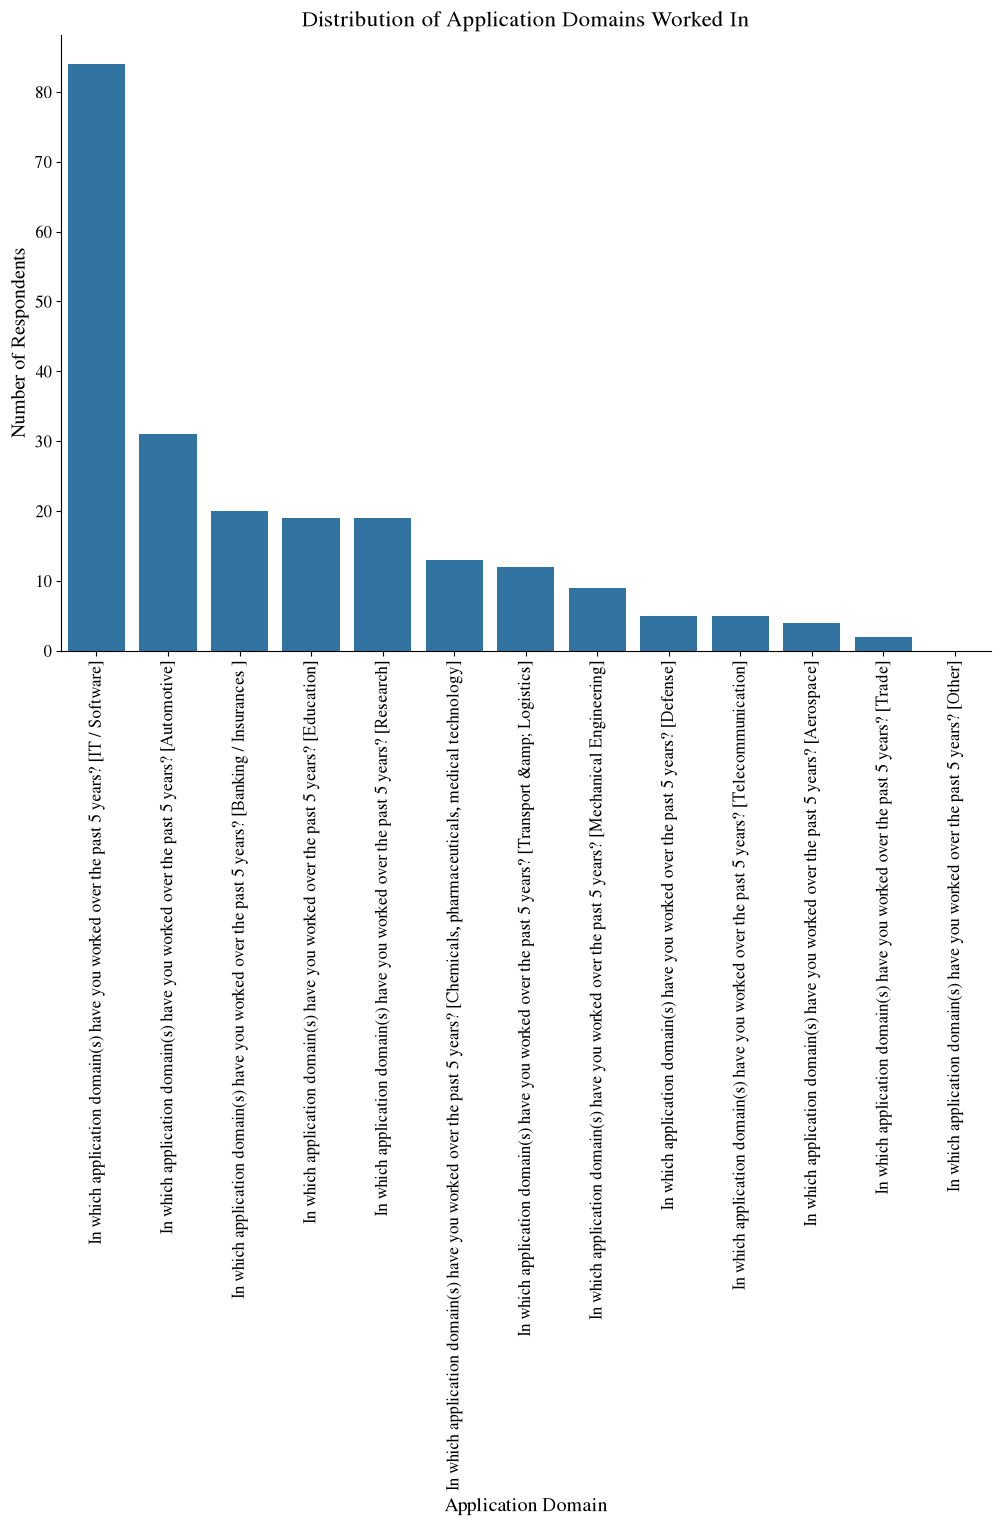

In [10]:


# Define the columns for analysis
application_columns = [
    "In which application domain(s) have you worked over the past 5 years? [Aerospace]",
    "In which application domain(s) have you worked over the past 5 years? [Automotive]",
    "In which application domain(s) have you worked over the past 5 years? [Banking / Insurances ]",
    "In which application domain(s) have you worked over the past 5 years? [Chemicals, pharmaceuticals, medical technology]",
    "In which application domain(s) have you worked over the past 5 years? [Defense]",
    "In which application domain(s) have you worked over the past 5 years? [Education]",
    "In which application domain(s) have you worked over the past 5 years? [IT / Software]",
    "In which application domain(s) have you worked over the past 5 years? [Mechanical Engineering]",
    "In which application domain(s) have you worked over the past 5 years? [Research]",
    "In which application domain(s) have you worked over the past 5 years? [Telecommunication]",
    "In which application domain(s) have you worked over the past 5 years? [Trade]",
    "In which application domain(s) have you worked over the past 5 years? [Transport &amp; Logistics]",
    "In which application domain(s) have you worked over the past 5 years? [Other]"
]

# Count the occurrences of 'Y' in each column
application_counts = df[application_columns].apply(lambda x: (x == 'Yes').sum()).sort_values(ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=application_counts.index, y=application_counts.values)
plt.xticks(rotation=90)
plt.title('Distribution of Application Domains Worked In')
plt.xlabel('Application Domain')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

# Analysis

## Use of GenAI (RQ1)

In [11]:
usage_indexes = [42,43,44,45,47,49,51,53]

usage_df = df.iloc[:, usage_indexes]

usage_df.head(5)

,How often do you use ChatGPT or similar AI chatbots?,How often do you use ChatGPT or similar AI chatbots? [Other],Have you already used / applied GenAI for RE-related disciplines in your professional work?,"For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Elicitation]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Analysis &amp; Negotiation]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Specification / Requirements Modeling]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Validation / Quality Assurance]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Management]"
0,Daily,NaN,Yes,Yes,Yes,Yes,No,No
1,Daily,NaN,Yes,No,Yes,Yes,No,No
2,At least once a week,NaN,Yes,No,No,No,Yes,No
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Daily,NaN,Yes,No,Yes,Yes,Yes,No


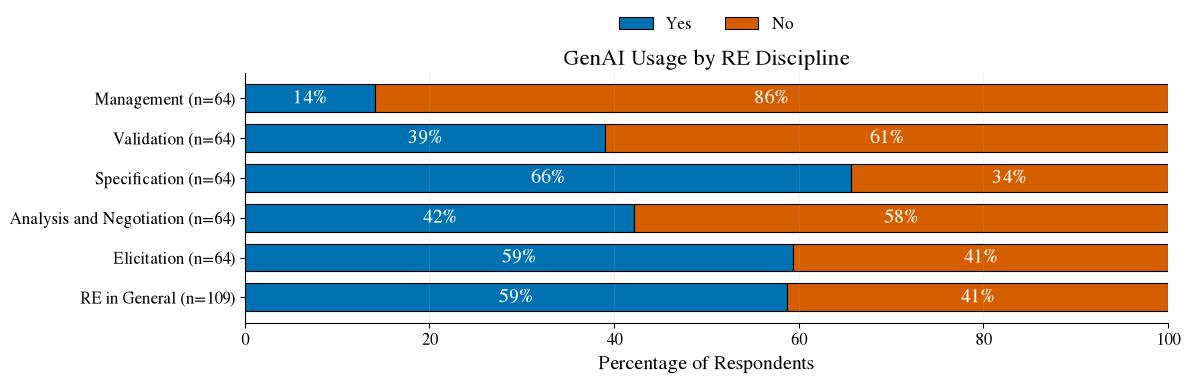

In [12]:
# Prepare plot_df_percentage and labels (same as you already did)
usage_columns_to_plot = usage_df.columns[2:]
non_null_counts = usage_df[usage_columns_to_plot].notna().sum()

yes_counts, no_counts, column_names = [], [], []
for col in usage_columns_to_plot:
    vc = usage_df[col].value_counts()
    yes_counts.append(vc.get('Yes', 0))
    no_counts.append(vc.get('No', 0))
    column_names.append(col)

plot_df = pd.DataFrame({'Yes': yes_counts, 'No': no_counts}, index=column_names)
plot_df_percentage = plot_df.apply(lambda x: x / x.sum() * 100 if x.sum() else x, axis=1)

shortened_column_names = [
    "RE in General", "Elicitation", "Analysis and Negotiation",
    "Specification", "Validation", "Management"
]
name_map = dict(zip(column_names, shortened_column_names))
non_null_counts = non_null_counts.rename(index=name_map)
plot_df_percentage.index = [f"{name_map[c]} (n={non_null_counts[name_map[c]]})" for c in column_names]

# Plot with unified style
plot_yesno_percentage_barh(
    plot_df_percentage=plot_df_percentage,
    title="GenAI Usage by RE Discipline",
    savepath="usage.pdf"
)

### Usage comments

In [13]:
usage_comments_indexes = [46,48,50,52,54,56]

usage_comments_df = df.iloc[:, usage_comments_indexes]

usage_comments_df.head(5)

,"For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Elicitation][Comment]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Analysis &amp; Negotiation][Comment]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Specification / Requirements Modeling][Comment]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Validation / Quality Assurance][Comment]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Management][Comment]","For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Other comment]"
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,specifications analysis,writing specifications,NaN,NaN,NaN
2,NaN,NaN,NaN,Writing Acceptance criteria,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Identify conflicting requirements in a large n...,Reformulating requirements.,Double-checking if derived requirements cover ...,NaN,NaN


In [14]:
# Print non-empty responses for each column in usage_comments_df
print("Non-empty responses in usage_comments_df by column:")
for col in usage_comments_df.columns:
    non_empty_comments = usage_comments_df[col].dropna()
    if not non_empty_comments.empty:
        print(f"\n--- {col} ---")
        for index, comment in non_empty_comments.items():
            print(f"{index}: {comment}")

Non-empty responses in usage_comments_df by column:

--- For which of the following RE-related disciplines did you use / apply GenAI?Please check all RE-related disciplines for which you have used GenAI and provide a short description of the particular tasks / goals that have been supported by AI (e.g., preparation of stakeholder interviews, analysis of elicited interview data, specification of user stories, etc.) [Requirements Elicitation][Comment] ---
5: Preperation
12: Elicitation techniques, determining unknown stakeholders
16: Generation of questions to the stakeholders
18: Extracting Requirements of Documents (e.g. Rulebooks, Implementation Guidelines)
19: Document Archaeology 
22: Writing user stories, summarizing documents 
29: Persona creation
41: preperation of project context
43: Only isolated pilots: Extract Requirements from feedback, support requests, informal documents, prior projects
47: literature search, summery, essenz forming
57: derive Requirements from unstructure

## Limitations and Threats (RQ2)

### What prevented practitioners from using GenAI?

In [15]:
# Columns 58-70
prevention_indexes = list(range(58, 71))

prevention_df = df.iloc[:, prevention_indexes]

prevention_df

,What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Lack of awareness or knowledge],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Lack of support / tools],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Lack of time],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Insufficient quality / availability of input data ],"What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Unclear, inconsistent, low-quality results]",What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Uncertainty about ROI (Return on Investment)],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Unclear or inconsistent results],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Cultural resistance and organizational inertia],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Using AI is forbidden by my organization],"What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Ethical and legal concerns (e.g., data privacy)]",What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Limited scope of AI applications in RE],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Fear of job displacement],What reasons prevent(ed) you from using GenAI in RE-related disciplines in your professional work? [Other]
0,No,Yes,No,Yes,Yes,No,No,Yes,Yes,No,No,No,GDPR and privacy concerns
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No,No,No,No,No,Yes,No,No,No,No,No,No,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,No,Yes,Yes,Yes,No,No,No,No,No,No,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,No,No,Hallucination in results
146,No,No,No,Yes,No,No,Yes,No,No,No,No,No,NaN
147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,No,No,No,No,Yes,No,No,No,No,Yes,Yes,No,NaN


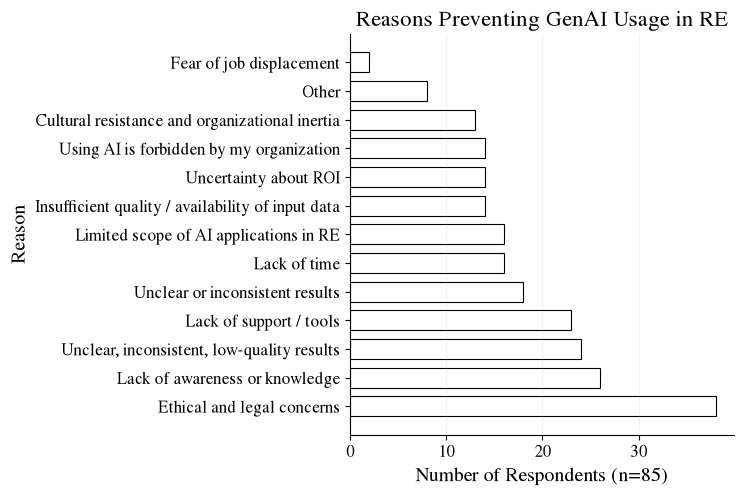

In [16]:
# Reasons preventing GenAI usage in RE
plot_yes_counts_barh(
    df=prevention_df,
    title="Reasons Preventing GenAI Usage in RE",
    ylabel="Reason",
    label_func=label_strip_brackets_and_parens,
    savepath="prevention.pdf"
)

### What threats and limitations do practioners see?

In [17]:
# Columns 160-175
threats_indexes = list(range(160, 176))

threats_df = df.iloc[:, threats_indexes]

threats_df

,"In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Data quality and availability]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Bias in AI models]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Lack of transparency and explainability]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Over-reliance on AI]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Contextual understanding and ambiguity handling]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Ethical and legal concerns]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Integration challenges (i.e., integrating AI in existing RE processes)]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Maintenance and adaptation (i.e., keeping the AI models up to date)]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Loss of human intuition and judgement]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Resistance to adoption]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Scalability issues]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Cost and ressource constraints]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Hallucinations(i.e., generated output that is nonsensical, inaccurate or not based on training data)]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Confidentiality]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [I don't see any limitations / threats]","In the following, you find a list of limitation / threats. Please select up to three limitations / threats that you see concerning AI in RE? [Other]"
0,No,Yes,No,No,No,Yes,No,No,No,No,No,No,No,Yes,No,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Yes,No,No,No,Yes,No,Yes,No,No,No,No,No,No,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Yes,No,Yes,No,No,No,No,No,No,No,No,No,Yes,No,No,NaN
146,Yes,No,No,No,No,No,Yes,No,No,No,No,No,Yes,No,No,NaN
147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,Yes,No,No,No,No,No,No,No,No,No,No,No,Yes,Yes,No,NaN


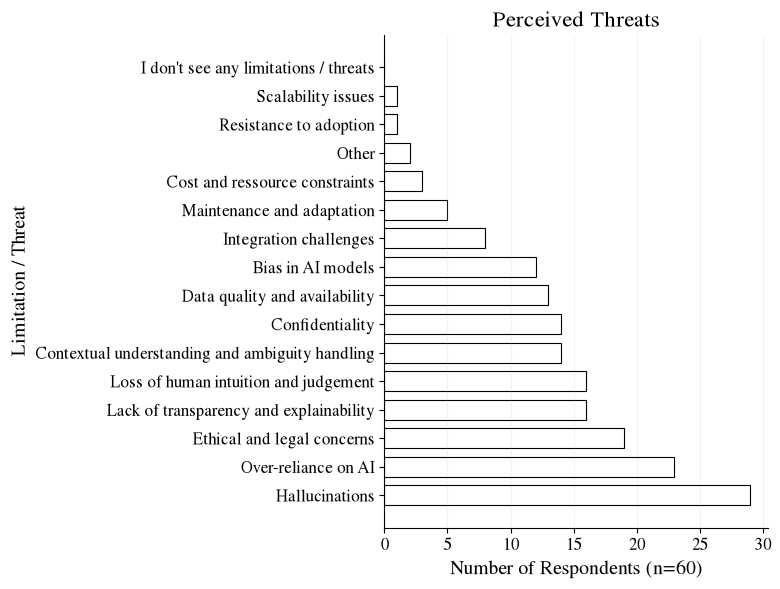

In [18]:
# Perceived threats / limitations
plot_yes_counts_barh(
    df=threats_df,
    title="Perceived Threats",
    ylabel="Limitation / Threat",
    label_func=label_strip_brackets_and_parens,
    savepath="threats.pdf"
)

## Experiences (RQ3)

### Elicitation

Prepare a focused dataframe

In [19]:
# Columns 73-91
elicitation_indexes = list(range(73, 92))

# select all columns from df where index is in elicitation_indexes
elicitation_df = df.iloc[:, elicitation_indexes]

elicitation_df.head(5)

,"In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Analysis of elicited data(e.g., gained from interviews, surveys, field studies,document analysis)][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Analysis of elicited data(e.g., gained from interviews, surveys, field studies,document analysis)][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creativity / ideation(e.g., generating (innovative) ideas / requirements)][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creativity / ideation(e.g., generating (innovative) ideas / requirements)][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Performing domain analysis][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Performing domain analysis][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification / analysis of stakeholders and their needs(e.g., generating personas)][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification / analysis of stakeholders and their needs(e.g., generating personas)][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Analysis of as-is situations / as-is scenarios][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Analysis of as-is situations / as-is scenarios][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Preparation of surveys / interview guidelines][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Preparation of surveys / interview guidelines][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ELICITATION. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Preparation of workshops / focus groups][Scale 1]","In the following, y

Call plotting for elicitation df

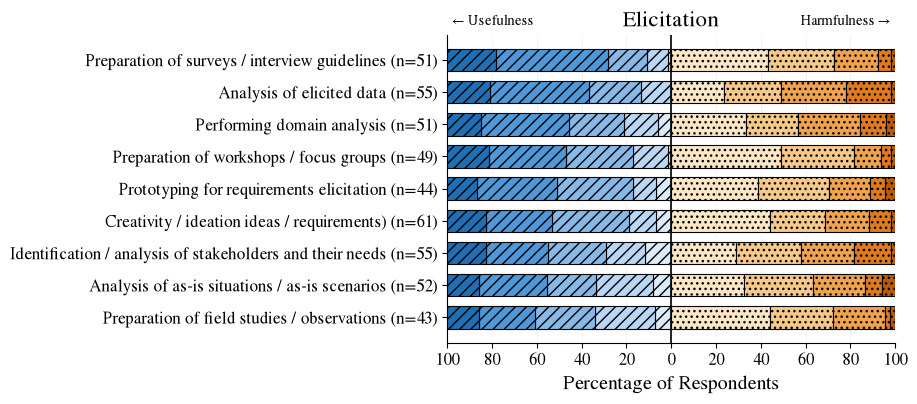

In [20]:
# Elicitation
plot_diverging_usefulness_harmfulness(
    elicitation_df,
    title_prefix="Elicitation",
    savepath="elicitation_assessment.pdf",
    show_legend=False
)

### Analysis and Negotiation

In [21]:
# Columns 94-112
analysis_indexes = list(range(94, 113))

# select all columns from df where index is in analysis_indexes
analysis_df = df.iloc[:, analysis_indexes]

analysis_df.head(5)

,"In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements prioritization][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements prioritization][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Conflict identification and resolution][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Conflict identification and resolution][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Feasibility analysis / Risk analysis][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Feasibility analysis / Risk analysis][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements refinement and clarfication][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements refinement and clarfication][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Stakeholder alignment and consensus building][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Stakeholder alignment and consensus building][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements categorization and grouping][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements categorization and grouping][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Trade-off analysis][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS ANALYSIS &amp; NEGOTIATION.Based on your experience or estimation, ple

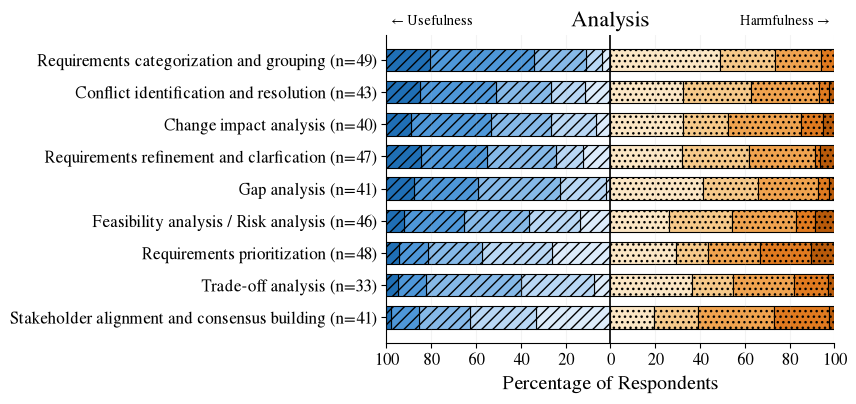

In [22]:
# Analysis
plot_diverging_usefulness_harmfulness(
    analysis_df,
    title_prefix="Analysis",
    savepath="analysis_assessment.pdf",
    show_legend=False
)

### Specification & Modeling

In [23]:
# Columns 115-127
specification_indexes = list(range(115, 128))

# select all columns from df where index is in specification_indexes
specification_df = df.iloc[:, specification_indexes]

specification_df.head(5)

,"In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creating document structures][Scale 1]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creating document structures][Scale 2]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Drafting specifications][Scale 1]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Drafting specifications][Scale 2]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Formulating requirements][Scale 1]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Formulating requirements][Scale 2]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creating use case descriptions][Scale 1]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creating use case descriptions][Scale 2]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creating diagrams (e.g., UML models)][Scale 1]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creating diagrams (e.g., UML models)][Scale 2]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Defining acceptance criteria][Scale 1]","In the following, you find a set of key tasks related to REQUIREMENTS SPECIFICATION / REQUIREMENTS MODELING.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Defining acceptance criteria][Scale 2]","Are there any further specification- / modeling-related tasks or goals for which GenAI could be useful / be harmful?If yes, please list them here and assess the degree of usefulness / harmfulness of AI."
0,Moderately useful,I don't know,Moderately useful,I don't know,Moderately useful,I don't know,Moderately useful,I don't know,Moderately useful,I don't know,Moderately useful,I don't know,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,Na

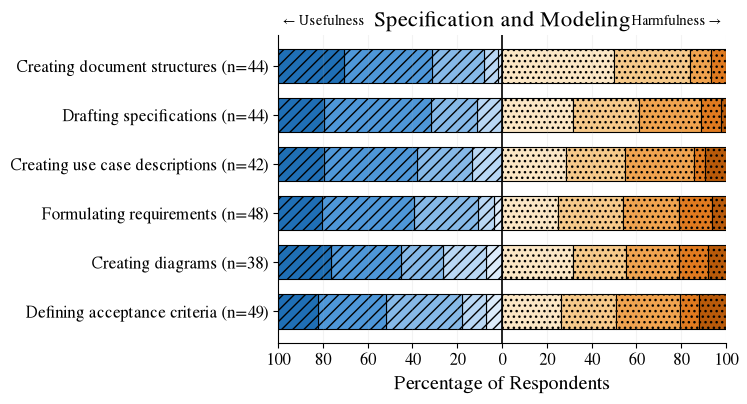

In [24]:
plot_diverging_usefulness_harmfulness(
    specification_df,
    title_prefix="Specification and Modeling",
    savepath="specification_assessment.pdf",
    show_legend=False
)

### Validation and QA

In [25]:
# Columns 130-146
validation_indexes = list(range(130, 147))

# select all columns from df where index is in validation_indexes
validation_df = df.iloc[:, validation_indexes]

validation_df.head(5)

,"In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Validation against business objectives][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Validation against business objectives][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Validation against stakeholder needs][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Validation against stakeholder needs][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creation of test cases(e.g., to verify testability)][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Creation of test cases(e.g., to verify testability)][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification of inconsistencies][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification of inconsistencies][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification of unnecessary / incorrect requirements][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification of unnecessary / incorrect requirements][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification of incomplete / missing requirements][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification of incomplete / missing requirements][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS VALIDATION / QUALITY ASSURANCE.Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Identification of requirements that are difficult to 

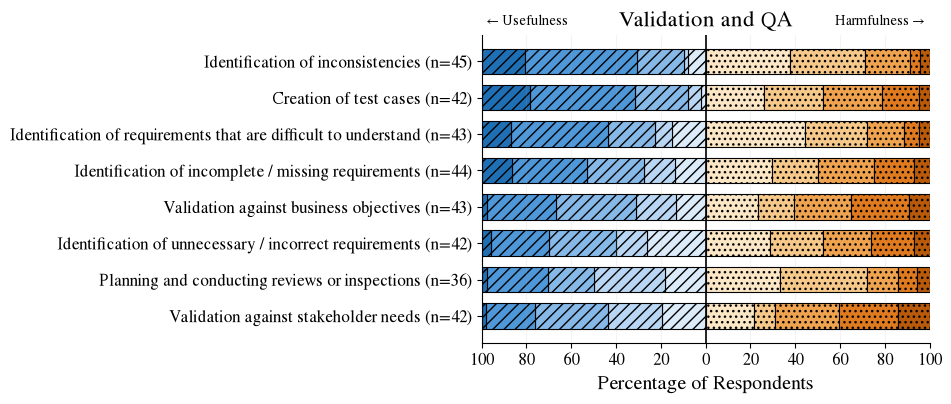

In [26]:
plot_diverging_usefulness_harmfulness(
    validation_df,
    title_prefix="Validation and QA",
    savepath="validation_assessment.pdf",
    show_legend=False
)

### Management

In [27]:
# Columns 149-159
management_indexes = list(range(149, 160))

# select all columns from df where index is in management_indexes
management_df = df.iloc[:, management_indexes]

management_df.head(5)

,"In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Maintain requirements traceabilty][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Maintain requirements traceabilty][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Change management][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Change management][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Configuration management (e.g., version control, document management)][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Configuration management (e.g., version control, document management)][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements tracking and monitoring][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements tracking and monitoring][Scale 2]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements process assessment(e.g., auditing)][Scale 1]","In the following, you find a set of key tasks and goals related to REQUIREMENTS MANAGEMENT. Based on your experience or estimation, please assess both the usefulness and harmfulness that GenAI could provide to these tasks / goals. [Requirements process assessment(e.g., auditing)][Scale 2]","Are there any further management-related tasks or goals for which GenAI could be useful / be harmful?If yes, please list them here and assess the degree of usefulness / harmfulness of AI."
0,Not useful at all,I don't know,Not useful at all,I don't know,Not useful at all,I don't know,Not useful at all,I don't know,Not useful at all,I don't know,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Not useful at all,I don't know,Not useful at all,I don't know,Not useful at all,I don't know,Not useful at all,I don't know,Not useful at all,I don't know,NaN


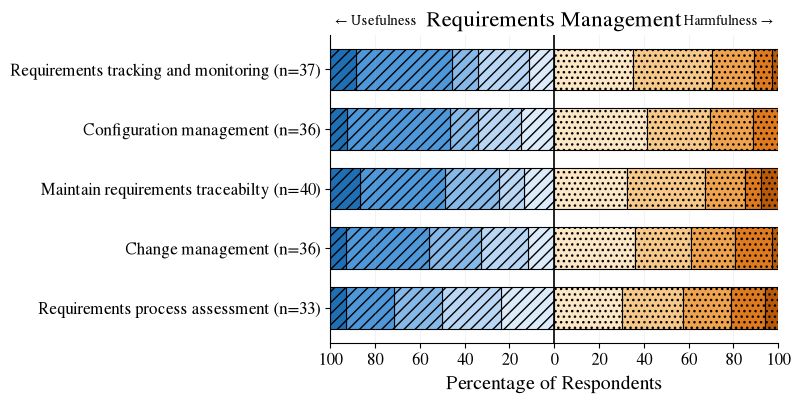

In [28]:
plot_diverging_usefulness_harmfulness(
    management_df,
    title_prefix="Requirements Management",
    savepath="management_assessment.pdf",
    show_legend=False
)

## Training and Skills (RQ4)

### What skills need to change?
Select relevant columns

In [29]:
skills_indexes = [188,189]

skills_df = df.iloc[:, skills_indexes]

skills_df.head(5)

,"Do you think the skill set of requirements engineers will need to change as AI becomes more prevalent in requirements engineering?If yes, please specify which skills you believe will be affected or will need to change in the comments field.","Do you think the skill set of requirements engineers will need to change as AI becomes more prevalent in requirements engineering?If yes, please specify which skills you believe will be affected or will need to change in the comments field. [Comment]"
0,Yes,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,Yes,"Definitely needs to be more technical, having ..."


Response Counts for Skill Set Change (n=60):


,Count
"Do you think the skill set of requirements engineers will need to change as AI becomes more prevalent in requirements engineering?If yes, please specify which skills you believe will be affected or will need to change in the comments field.",
Yes,54
No,6


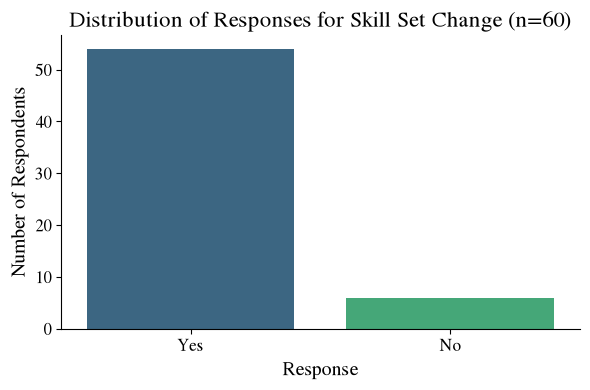

In [30]:
# Select the first column of skills_df
skills_column = skills_df.iloc[:, 0]

# Count the occurrences of 'Yes' and 'No', excluding NaN values
skills_counts = skills_column.value_counts().loc[['Yes', 'No']]

# Calculate the total number of responses (non-NaN values)
total_skills_responses = skills_column.count()

# Create a DataFrame for the table
skills_table_df = pd.DataFrame({'Count': skills_counts})

# Display the table with title
print(f"Response Counts for Skill Set Change (n={total_skills_responses}):")
display(skills_table_df)

# Create a bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=skills_counts.index, y=skills_counts.values, palette='viridis', hue=skills_counts.index, legend=False) # Added hue and legend=False
plt.title(f'Distribution of Responses for Skill Set Change (n={total_skills_responses})')
plt.xlabel('Response')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

In [31]:
# Select the second column of skills_df
skills_comments_column = skills_df.iloc[:, 1]

# Filter out non-empty responses
non_empty_comments = skills_comments_column.dropna()

# Print the non-empty responses with index and linebreaks
print("Non-empty responses in the second column of skills_df:")
for index, comment in non_empty_comments.items():
    print(f"{index}: {comment}\n")

Non-empty responses in the second column of skills_df:
4: Definitely needs to be more technical, having an interest in AI developments in general and an understanding of how AI tools/methods can be implemented in an operational way.

12: Proofreading 

16: The way a requirements engineer  works is changing, so do the skills

19: to know how to prompt, how to deal with the system immanent failures

22: AI will help RE’s, but not replace them or change the work they do. I think AI will mostly provide more efficient ways of working, but an RE has to still be in charge

27: requirements specification and validation

40: We will all be confronted with GenAI in our working environment and better be able to use it properly.

43: Risk awareness and awareness in what can and Can't do AI. 
Sensibility that reviews need to to be done with the same mindset as before.
More overview knowledge less detail accuracy. (Keep the context overview beeing less the writer)

48: Prompt engineering is necessar

### Training Interest

In [32]:
# Even columns between 176-186
traininginterest_indexes = list(range(176, 188, 2))

# Odd columns between 177-187
interestcomment_indexes = list(range(177, 189,2))

traininginterest_df = df.iloc[:, traininginterest_indexes]

interestcomment_df = df.iloc[:, interestcomment_indexes]

traininginterest_df

,"For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [AI-supported Requirements Elicitation]","For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [AI-supported Requirements Analysis &amp; Negotiation]","For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [AI-supported Requirements Specification / Requirements Modeling]","For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [AI-supported Requirements Validation / Quality Assurance]","For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [AI-supported Requirements Management]","For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [Other]"
0,No,Yes,No,No,No,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,No,No,Yes,Yes,No,NaN
...,...,...,...,...,...,...
145,Yes,No,No,No,No,NaN
146,No,No,No,No,No,NaN
147,NaN,NaN,NaN,NaN,NaN,NaN
148,Yes,Yes,Yes,Yes,Yes,NaN


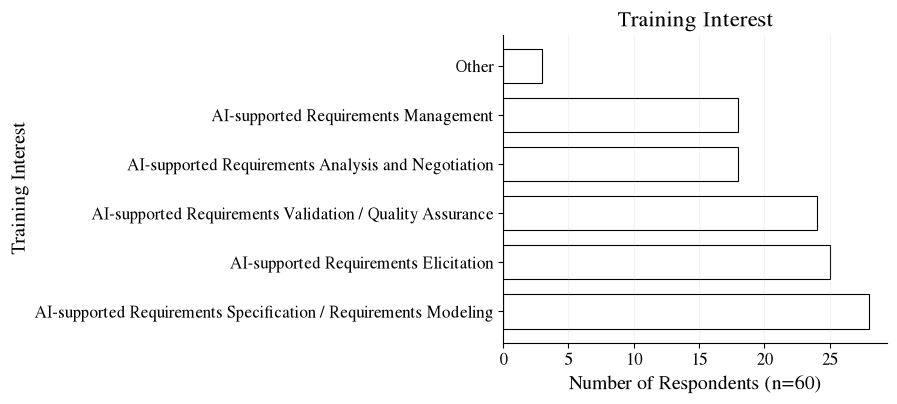

In [33]:
# Training interest

import html

def clean_label(label: str) -> str:
    """Unescape HTML entities and replace '&' with 'and'."""
    if not isinstance(label, str):
        return label
    text = html.unescape(label)
    return text.replace('&', 'and')

plot_yes_counts_barh(
    df=traininginterest_df,
    title="Training Interest",
    ylabel="Training Interest",
    label_func=label_from_brackets,
    savepath="training_interest.pdf"
)

In [34]:
# Print non-empty responses for each column in interestcomment_df
print("Non-empty responses in interestcomment_df by column:")
for col in interestcomment_df.columns:
    non_empty_comments = interestcomment_df[col].dropna()
    if not non_empty_comments.empty:
        print(f"\n--- {col} ---")
        for index, comment in non_empty_comments.items():
            print(f"{index}: {comment}")

Non-empty responses in interestcomment_df by column:

--- For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [AI-supported Requirements Elicitation][Comment] ---
19: marked analyses, 
58: available tools, working with document inputs, AI assistants
70: Prompt management in RE
79: how to create high-quality questionnaire with AI? How to do the data analysis to find values information?
82: I need all of them
89: Analysis of legacy documents, audios, videos
105: How to achieve a better prompt for the AI
117: How to proceed in very specific domains
132: To get the needs from customers
145: prepare interviews etc.

--- For which of the following activities would you like to receive trainings (if any)?For each activity you selected, please provide examples of training topics that would interest you. [AI-supported Requirements Analysis &amp; Negotiation][Comment]

### Preferred training formats.
Select the relevant columns

In [35]:
# Columns 190-200
trainingformat_indexes = list(range(190, 201))

trainingformat_df = df.iloc[:, trainingformat_indexes]

trainingformat_df.head(5)

,"Which training format would you prefer? You can select up to three training formats. [“Classical Training” (e.g., Classroom Training, Face-2-Face Training)]",Which training format would you prefer? You can select up to three training formats. [Community of practice],Which training format would you prefer? You can select up to three training formats. [Newsletter],"Which training format would you prefer? You can select up to three training formats. [Workshops, tutorials and hands-on labs]",Which training format would you prefer? You can select up to three training formats. [Online courses and webinars],Which training format would you prefer? You can select up to three training formats. [Mentoring programs],Which training format would you prefer? You can select up to three training formats. [Blended learning programs],Which training format would you prefer? You can select up to three training formats. [Case study analysis and group discussions],Which training format would you prefer? You can select up to three training formats. [Conferences ],Which training format would you prefer? You can select up to three training formats. [Hackathons],Which training format would you prefer? You can select up to three training formats. [Other]
0,Yes,Yes,No,No,Yes,No,No,No,No,No,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,No,No,No,Yes,No,No,No,No,Yes,Yes,NaN


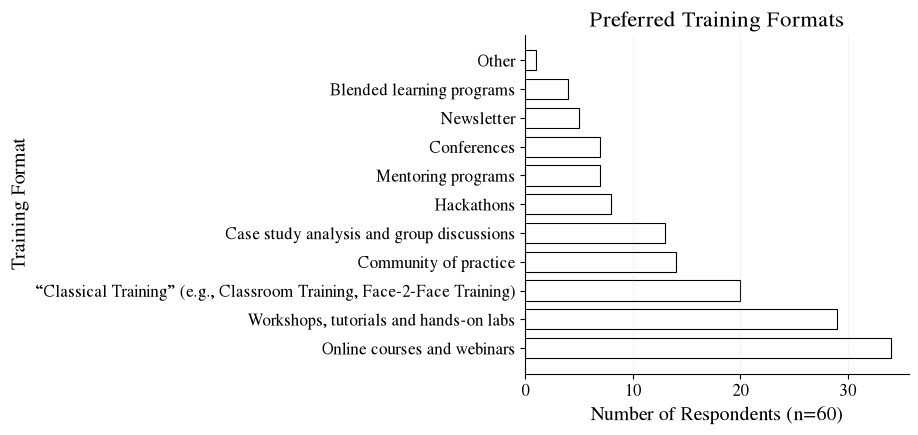

In [36]:
# Preferred training formats
plot_yes_counts_barh(
    df=trainingformat_df,
    title="Preferred Training Formats",
    ylabel="Training Format",
    label_func=label_from_brackets,
    savepath="training_format.pdf"
)